# Building Chatbot with multiple tools

Tavily est un moteur de recherche conçu pour les agents IA.

Tavily sert principalement à donner à l'agent :

- un accès au web
- de la recherche internet temps réel
- du RAG web
- des sources récentes

Les LLM :

- ne connaissent pas les infos récentes
- ne naviguent pas sur internet seuls

Donc Tavily permet à l’agent de :

- chercher sur le web
- récupérer des pages
- résumer des résultats

Loader:
Je charge des documents

Wrapper:
Je parle à une API

Tool:
Je suis utilisable par un agent IA

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
#api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500) # 2 documents de 500 caractères
#arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

### Le Wrapper avec l'API d'Arxiv n'est pas stable avec l'évolution de Langchain. La solution est l'utilisation de requests et feedparser

In [3]:
import requests # Permet de faire des requêtes HTTP
import feedparser # L’API arXiv retourne du XML Atom. feedparser transforme le XML compliqué en objets Python simples

url = "https://export.arxiv.org/api/query" # endpoint officiel de l’API arXiv

params = {
    "search_query": "all:Attention Is All You Need",
    "start": 0,
    "max_results": 2
}

response = requests.get(url, params=params) # envoie la requête et récupère la réponse du serveur

feed = feedparser.parse(response.text)

for entry in feed.entries:
    print(entry.title)
    print(entry.summary[:500])

Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a
"All You Need" is Not All You Need for a Paper Title: On the Origins of a Scientific Meme
The 2017 paper ''Attention Is All You Need'' introduced the Transformer architecture-and inadvertently spawned one of machine learning's most persistent naming conventions. We analyze 717 arXiv preprints containing ''All You Need'' in their titles (2009-2025), finding exponential growth ($R^2$ > 0.994) following t

In [4]:
def search_arxiv_papers(query: str) -> str:
    """Search scientific papers on arxiv."""

    import requests
    import feedparser

    url = "https://export.arxiv.org/api/query"

    response = requests.get(
        url,
        params={
            "search_query": f"all:{query}",
            "start": 0,
            "max_results": 2
        }
    )

    feed = feedparser.parse(response.text)

    if not feed.entries:
        return "No paper found"

    results = []

    for paper in feed.entries[:2]:
        results.append(
            f"""
Title: {paper.title}

Summary:
{paper.summary[:500]}
"""
        )

    return "\n\n".join(results)

In [25]:
import wikipedia.wikipedia as wp

wp.API_URL = "https://en.wikipedia.org/w/api.php"
wp.USER_AGENT = "NicolasAgenticAI/1.0 (nicolas.sales77@gmail.com)"

from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

api_wrapper = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)

wiki = WikipediaQueryRun(api_wrapper=api_wrapper)

print(wiki.invoke("What is machine learning?"))

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m


In [26]:
from dotenv import load_dotenv
load_dotenv()

import os

In [27]:
# Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [28]:
tavily.invoke("Provide me the recent AI news with the date")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': "April 29, 2026\n\n#### Enterprise\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n### How E.ON uses SAP S/4HANA to modernise the grid with AI\n\nAI in Action\n\nJune 3, 2026\n\n### Anthropic IPO filing marks AI maturing into enterprise utility\n\nAI Business Strategy\n\nJune 2, 2026\n\n#### Industries\n\n### Meta Business Agent drives AI-powered conversational commerce\n\nRetail & Logistics AI\n\nJune 4, 2026\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### RingCentral adds Shopify, Calendly, and WhatsApp to AI Receptionist\n\nService Industry AI\n\nMay 8, 2026\n\n#### Deep Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026 [...] ## Latest\n\nClose-up of mobile sma

In [29]:
# Combine all the tools in the list

tools = [search_arxiv_papers,wiki,tavily]

In [30]:
# Initialize LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("Hello")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.027449327, 'completion_tokens_details': None, 'prompt_time': 0.002468287, 'prompt_tokens_details': None, 'queue_time': 0.018983707, 'total_time': 0.029917614}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eacc9-3459-7c03-b89a-7a45badb23e4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [31]:
llm_with_tools=llm.bind_tools(tools)

In [32]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3xywgs3r1', 'function': {'arguments': '{"query":"latest AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 461, 'total_tokens': 481, 'completion_time': 0.033496881, 'completion_tokens_details': None, 'prompt_time': 0.029106622, 'prompt_tokens_details': None, 'queue_time': 0.045040277, 'total_time': 0.062603503}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eacc9-3875-7ca1-97fe-37d1a233710a-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI news'}, 'id': '3xywgs3r1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 461, 'output_tokens': 20, 'total_tokens': 481})

In [33]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'AI news'},
  'id': '2hkeqhxtx',
  'type': 'tool_call'}]

In [34]:
# State schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages # Pour fusionner 2 listes de messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

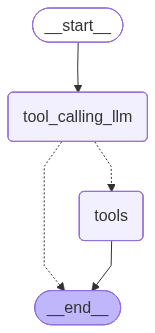

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # Si le dernier message (result) de l'assistant est un appel d'outil -> conditions de l'outils sont transmises à l'outils
    # Si le dernier message (result) de l'assistant n'est pas un appel d'outil -> tools_condition transmis à END
    tools_condition # retounne soit tools soit END. Même si le node tools n est pas dans add_conditional_edges, tools_condition retourne automatiquement tools
)

builder.add_edge("tools",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
messages = graph.invoke({"messages": [HumanMessage(content="1706.03762")]})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  search_arxiv_papers (6n9p0kcfg)
 Call ID: 6n9p0kcfg
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: search_arxiv_papers


Title: Attention Is All You Need

Summary:
The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more 



Title: GLU Variants Improve Transformer

Summary:
Gated Linear Units (arXi

In [37]:
messages = graph.invoke({"messages": [HumanMessage(content="Give me the top 10 recent news on AI")]})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Give me the top 10 recent news on AI
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (a3q2yxf0c)
 Call ID: a3q2yxf0c
  Args:
    query: AI recent news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com", "content": "April 29, 2026\n\n#### Enterprise\n\n### How C3 AI agents will automate predictive maintenance for Shell\n\nAI in Action\n\nJune 5, 2026\n\n### How E.ON uses SAP S/4HANA to modernise the grid with AI\n\nAI in Action\n\nJune 3, 2026\n\n### Anthropic IPO filing marks AI maturing into enterprise utility\n\nAI Business Strategy\n\nJune 2, 2026\n\n#### Industries\n\n### Meta Business Agent drives AI-powered conversational commerce\

In [38]:
messages = graph.invoke({"messages": [HumanMessage(content="What is Machine Learning?")]})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fxagfkmv4)
 Call ID: fxagfkmv4
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
